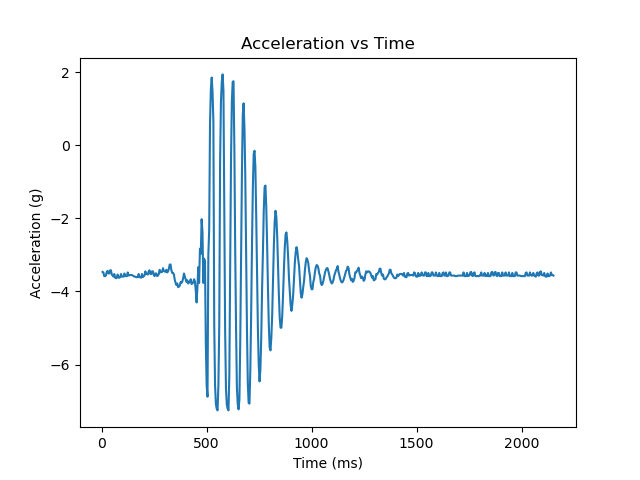

In [5]:
# As always, we start by importing our libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch # We'll need this for power spectral density estimation 

# Allow for interactive plotting in Jupyter notebooks, comment out to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package.
%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors


VCC = 5.01

# Zero g bias at 3.3 V is VCC / 2
ZERO_G_BIAS = VCC / 2

# Sensitivity at 3.3 V is ~340 mV / g
SENSITIVITY = 340e-3  # Convert to volts per g

data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/freq_2.csv")

# Convert raw Arduino data to volts
data["Voltage"] = data["Sensor 0 (raw)"] * VCC / 1023

# Subtract the zero g bias so signal is centered around 0 V
data["Voltage"] = data["Voltage"] - ZERO_G_BIAS

# Convert volts to g’s using the sensitivity
data["Acceleration (g)"] = data["Voltage"] / SENSITIVITY

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y= "Acceleration (g)", data= data)
plt.title("Acceleration vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration (g)")
mplcursors.cursor(hover=False)
plt.show()
